In [47]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
df = pd.read_csv('churn_clean.csv')

# Select features (independent variables) for prediction
features = ['Tenure', 'MonthlyCharge', 'Income', 'InternetService', 'Contract', 'TechSupport', 'OnlineSecurity']

# Define feature set X and target variable y
X = df[features]
y = df['Churn']

# One-hot encode categorical variables in X
X = pd.get_dummies(X, drop_first=True)

# Label encode the target variable y (Churn: Yes/No --> 1/0)
le = LabelEncoder()
y = le.fit_transform(y)

# Standardize the features to have mean 0 and variance 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a DataFrame for the scaled features
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Add the target variable back to the DataFrame
X_scaled_df['Churn'] = y

# Save the cleaned dataset to a CSV file
X_scaled_df.to_csv('cleaned_churn_data.csv', index=False)

In [49]:
# Separate features and target from the cleaned dataset
X = X_scaled_df.drop('Churn', axis=1)
y = X_scaled_df['Churn']

# Split into 70% training and 30% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Save training and testing sets to CSV files
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

Accuracy: 0.878
AUC: 0.9209340295790871


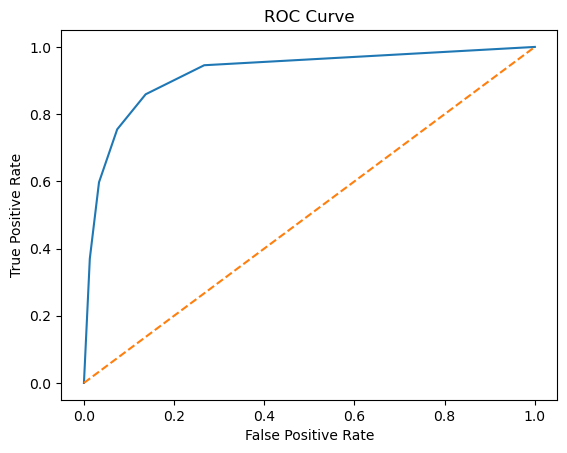

In [55]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# Create a KNN model with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

#(Kartik)

# Train the model on the training data
knn.fit(X_train, y_train)

# Predict churn on the testing data
y_pred = knn.predict(X_test)

# Get predicted probabilities for ROC curve
y_pred_prob = knn.predict_proba(X_test)[:, 1]

# Calculate and print model accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

# Calculate and print AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_pred_prob)
print('AUC:', auc)

# Create and plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

#(W3schools.com)